### Lab 02 - EDA - Ricardo 

### Context:

MISR stands for Multi-angle Imaging SpectroRadiometer. It is a sensor aboard NASA's Terra satellite, launched in 1999. What makes MISR special compared to a regular satellite camera is that it has 9 cameras, each pointing at Earth from a different angle simultaneously — like photographing the same scene from 9 different perspectives at the same moment.

Each pixel in the data covers a 275m × 275m patch of Earth's surface. Only the red band (visible red light) is used in this dataset, at full 275m resolution.

Radiance is the amount of red light energy the sensor detects bouncing back from that location. Higher number = brighter. The unit is physical light intensity.

We need multiple angles because ice/snow and clouds look differently depending on the angle you view them from. Ice/snow scatters light fairly evenly in all directions (isotropic). Clouds scatter much more light in the forward direction (anisotropic). This angular difference is the core idea the whole dataset is built around.


### Data Dictionary:
- y: y-coordinate (satellite image row coordinate, North-South direction). Higher value means further south. Low value means further north. 

- x: x-coordinate (satellite image column coordinate, East-West direction). Higher value means further east. Low value means further west.
    - X,Y: NOT latitude/longitude. They are pixel grid coordinates within the satellite's reference system. Togather they tell where on Earth that measurement was taken. 

- NDAI: Normalized Difference Angular Index, it's a ratio comparing the most extreme forward camera (DF, 70.5°) to the nadir camera (AN, 0°), computed over a 4x4 pixel neighborhood (1.1 km resolution)
    - Interpreation:
        - Ice/snow surface: Scatters light roughly equally in all directions. DF and AN see similar brightness. Numerator ≈ 0 → NDAI near 0
        - Cloud: Scatters much more light in the forward direction. DF (70.5° forward) sees much brighter signal than AN (straight down) → NDAI large and positive

- SD: The standard deviation of the nadir camera (AN) red radiance values within a small local neighborhood of pixels.
    - Interpreation:
        - Smooth ice/snow surface: Uniform brightness across the neighborhood → Low SD
        - Textured cloud or rough terrain: Brightness varies a lot across the neighborhood → High SD
    - Additional note: A smooth, flat ice surface can sometimes have low CORR (due to instrument noise dominating a very uniform signal). SD catches this case: if SD is very small, the surface is smooth and uniform → almost certainly ice, not cloud.

- CORR: The average linear correlation between radiance measurements from different camera angles, computed over a small 8x8 pixel
    - specifically average of the correlation between (AF and AN) and the correlation between (BF and AN)
    - Interpretation:
        - Ice/snow surface: The same patch of ground looks nearly identical from AF and AN angles, the surface doesn't move and scatters light evenly → High CORR
        - Cloud: A cloud is elevated above the surface. When the satellite views it from AF vs AN, it is actually photographing slightly different parts of the cloud because the cloud shifted in the registration. The same pixel coordinates see different parts of the cloud → Low CORR
    - Limitation: Low-altitude clouds can have high CORR (they're close to the surface, so the registration shift is small)

- DF: Radiance angle DF (forward-facing, 70.5 degrees)
- CF: Radiance angle CF (forward-facing, 60 degrees)
- BF: Radiance angle BF (forward-facing, 45.6 degrees)
- AF: Radiance angle AF (forward-facing, 26.1 degrees)
- AN: Radiance angle AN (straight-down, 0 degrees)
- label: expert label (+1: cloud, -1: not cloud, 0: unlabeled)

The core challenge: in most parts of the world, cloud detection is easy: clouds are bright, surfaces are dark. But in the Arctic, both clouds and ice/snow are bright and cold. The thing that differ between clouds and ice is how they scatter light at different angles.

In [1]:
import numpy as np
import glob
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# load labeled images into a dictionary
labeled = ["O013257", "O013490", "O012791"]
col_names = ["y", "x", "NDAI", "SD", "CORR", "DF", "CF", "BF", "AF", "AN", "label"]

labeled_data = {}
for name in labeled:
    npz = np.load(f"../data/{name}.npz")
    key = list(npz.files)[0]
    # load array into memory
    # this has shape: N_pixels rows (one per satellite observation/pixel), 11 columns (y, x, NDAI, SD, CORR, DF, CF, BF, AF, AN, label).
    arr = npz[key]
    # store the array in a dictionary
    labeled_data[name] = arr
    print(arr.shape)   # (N, 11)

(115000, 11)
(115032, 11)
(114973, 11)


The shape can be interpreted as:
115,000 rows  →  one row per pixel (satellite observation)
11 columns    →  measurements recorded at that pixel

Data is stored as a table (not a grid)

The satellite image is physically a 2D picture (like a photo), but it's stored as a flat list of pixels because not every (x, y) coordinate has data. The satellite only records where it flew over. 

In [3]:
# let's look at the raw numbers 
# store image 'O013257' into DataFrame
df = pd.DataFrame(labeled_data['O013257'], columns=col_names)
df.head()

,y,x,NDAI,SD,CORR,DF,CF,BF,AF,AN,label
0,2.0,70.0,0.528076,1820.998779,0.900904,22692.50,19834.00,11228.50,8536.50,7008.25,0.0
1,2.0,71.0,0.593831,1169.416504,0.473416,23461.00,18388.50,11575.25,8993.25,5978.75,1.0
2,2.0,72.0,0.550953,1376.460571,0.861363,23831.75,16752.50,12560.25,9570.75,6900.00,1.0
3,2.0,73.0,0.550160,1389.984863,0.687417,23185.75,15590.75,14639.50,8372.50,6728.25,1.0
4,2.0,74.0,0.615813,1388.641357,0.486022,23047.75,16095.25,12771.50,7136.00,5480.00,1.0


In [4]:
# compute count, mean, std, min, 25th percentile, median, 75th percentile, max
df.describe()

,y,x,NDAI,SD,CORR,DF,CF,BF,AF,AN,label
count,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000,115000.000000
mean,193.012591,217.952287,0.163099,498.951855,0.540242,27633.237495,25899.689137,23939.927862,21914.087820,20185.363066,-0.259913
std,110.280751,86.910398,0.074897,721.752672,0.405618,4248.335502,4679.435297,4748.703339,4540.349484,4155.127877,0.740492
min,2.000000,65.000000,-0.158468,14.607972,-0.942551,6293.750000,4464.750000,3588.000000,3215.500000,3272.750000,-1.000000
25%,98.000000,143.000000,0.123142,48.245229,0.277339,26535.000000,25114.312500,23414.250000,21660.875000,20217.937500,-1.000000
50%,193.000000,218.000000,0.150698,194.343452,0.685812,28930.750000,27419.000000,25729.125000,23781.250000,21663.875000,0.000000
75%,289.000000,293.000000,0.175175,663.256058,0.873131,30356.500000,28825.750000,26767.750000,24349.500000,22368.062500,0.000000
max,383.000000,368.000000,0.724288,6695.496094,0.983018,48439.687500,34377.750000,33268.250000,32085.000000,30824.500000,1.000000


In [5]:
# let's check how many pixels are labeled cloud (+1), not-cloud (-1), and unlabeled (0). 
# this tells if the classes are balanced or not
df["label"].value_counts()

label
-1.0    50358
 0.0    44174
 1.0    20468
Name: count, dtype: int64

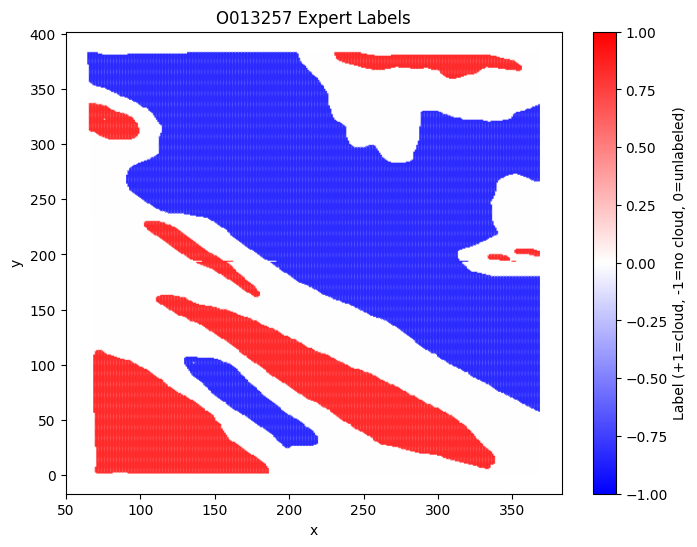

In [6]:
#  Plotting the spatial cloud map
arr = labeled_data["O013257"] 
y, x, label = arr[:,0], arr[:,1], arr[:,10]
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=label, cmap='bwr', s=0.1)
plt.colorbar(label="Label (+1=cloud, -1=no cloud, 0=unlabeled)")
plt.title("O013257 Expert Labels")
plt.xlabel("x"); plt.ylabel("y")
plt.show()


In [7]:
# now all 3 labeled images

# build dataframe, one per image, adding one more column to track which image each pixel came from

dfs = []
for name in labeled:
    npz = np.load(f"../data/{name}.npz")
    key = list(npz.files)[0]
    arr = npz[key]
    df_img = pd.DataFrame(arr, columns=col_names)
    df_img['image'] = name
    dfs.append(df_img)

df_all = pd.concat(dfs, ignore_index=True)

print(df_all.shape)
print(df_all['image'].value_counts())

(345005, 12)
image
O013490    115032
O013257    115000
O012791    114973
Name: count, dtype: int64


In [8]:
df_all.head(10)

,y,x,NDAI,SD,CORR,DF,CF,BF,AF,AN,label,image
0,2.0,70.0,0.528076,1820.998779,0.900904,22692.50,19834.00,11228.50,8536.50,7008.25,0.0,O013257
1,2.0,71.0,0.593831,1169.416504,0.473416,23461.00,18388.50,11575.25,8993.25,5978.75,1.0,O013257
2,2.0,72.0,0.550953,1376.460571,0.861363,23831.75,16752.50,12560.25,9570.75,6900.00,1.0,O013257
3,2.0,73.0,0.550160,1389.984863,0.687417,23185.75,15590.75,14639.50,8372.50,6728.25,1.0,O013257
4,2.0,74.0,0.615813,1388.641357,0.486022,23047.75,16095.25,12771.50,7136.00,5480.00,1.0,O013257
5,2.0,75.0,0.599688,1648.248657,0.766353,23816.75,16542.50,11906.00,6817.25,5960.00,1.0,O013257
6,2.0,76.0,0.610407,1721.405640,0.876248,22545.50,15483.50,10714.75,5835.00,5454.25,1.0,O013257
7,2.0,77.0,0.620928,1257.533081,0.790170,22437.50,17329.50,10950.25,8092.00,5247.25,1.0,O013257
8,2.0,78.0,0.446301,1204.977661,0.783406,22331.25,18433.75,13120.25,10536.50,8549.25,1.0,O013257
9,2.0,79.0,0.376849,1743.536987,0.901814,22287.75,18948.50,14851.50,12309.50,10087.25,1.0,O013257


In [9]:
df_all.describe()

,y,x,NDAI,SD,CORR,DF,CF,BF,AF,AN,label
count,345005.000000,345005.000000,345005.000000,345005.000000,345005.000000,345005.000000,345005.000000,345005.000000,345005.000000,345005.000000,345005.000000
mean,193.045443,217.895955,0.187572,591.668358,0.464002,27529.411195,25077.101970,22582.969798,20452.263583,18999.342919,-0.132610
std,110.274418,86.911772,0.096814,750.410181,0.392338,4576.050883,4458.922334,4424.135030,4307.260475,4005.152179,0.764449
min,2.000000,65.000000,-0.355057,13.329613,-0.942551,4904.000000,3536.750000,2777.750000,2170.500000,2089.250000,-1.000000
25%,98.000000,143.000000,0.128829,53.212029,0.160484,24954.500000,22371.250000,20216.750000,18798.250000,17700.500000,-1.000000
50%,193.000000,218.000000,0.161458,315.824890,0.534253,28552.250000,26387.500000,23791.250000,21443.250000,19921.500000,0.000000
75%,289.000000,293.000000,0.220603,832.616394,0.818286,30355.750000,28366.250000,25971.000000,23791.000000,21828.500000,0.000000
max,383.000000,368.000000,0.816864,8248.583008,0.983018,51807.125000,36623.750000,33268.250000,32085.000000,30824.500000,1.000000


In [10]:
df_all['label'].value_counts()

label
 0.0    137324
-1.0    126716
 1.0     80965
Name: count, dtype: int64

In [11]:
# lets plot all 3 images like before but using another package
import matplotlib.pyplot as plt       
import matplotlib.patches as mpatches  
import seaborn as sns

sns.set_theme(style="white", font_scale=1.2)


In [12]:
COLORS = {
     1: "#2C7BB6",   # blue  = cloud
    -1: "#E8A838",   # amber = not cloud
     0: "#CCCCCC"    # gray  = unlabeled
}

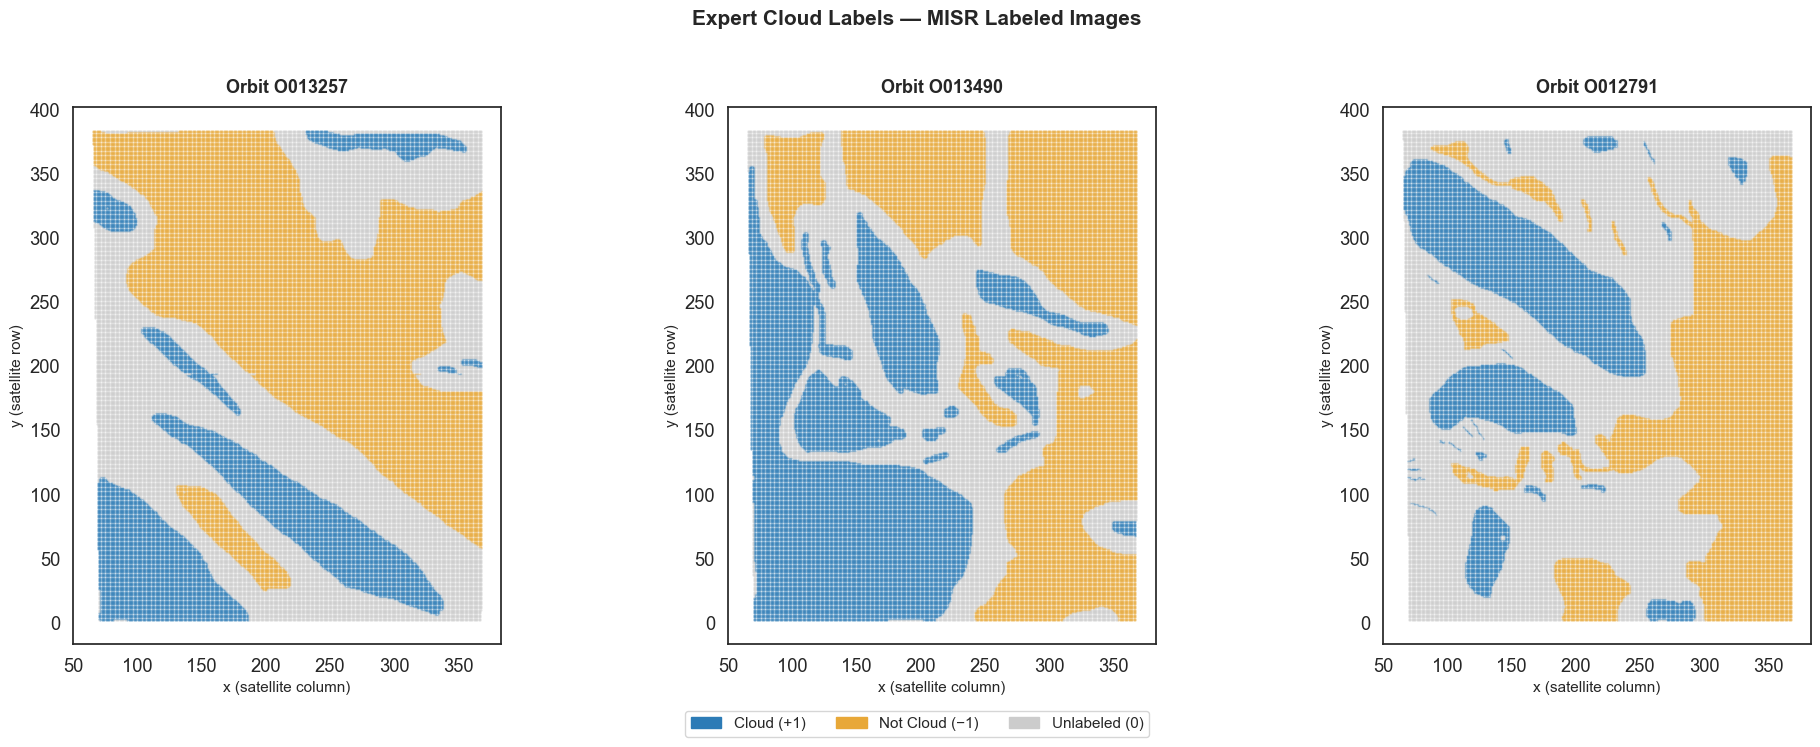

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, name in zip(axes, labeled):
    arr = labeled_data[name]
    y = arr[:, 0]
    x = arr[:, 1]
    label = arr[:, 10].astype(int)

    for lval, lname in [(1, "Cloud"), (-1, "Not Cloud"), (0, "Unlabeled")]:
        mask = label == lval
        ax.scatter(
            x[mask], y[mask],
            c=COLORS[lval],
            s=0.3,
            alpha=0.5,
            rasterized=True,
            label=lname
        )

    ax.set_title(f"Orbit {name}", fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("x (satellite column)", fontsize=11)
    ax.set_ylabel("y (satellite row)", fontsize=11)
    ax.set_aspect("equal")

handles = [
    mpatches.Patch(color=COLORS[1],  label="Cloud (+1)"),
    mpatches.Patch(color=COLORS[-1], label="Not Cloud (−1)"),
    mpatches.Patch(color=COLORS[0],  label="Unlabeled (0)")
]
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=11,
    frameon=True,
    edgecolor="#cccccc"
)


fig.suptitle(
    "Expert Cloud Labels — MISR Labeled Images",
    fontsize=15, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("./results/cloud_map_labeled.pdf", dpi=150, bbox_inches="tight")
plt.show()

Some comments from the output above:
- Observation 1: Clouds form spatial regions
    If you notice, cloud pixels cluster together into large contiguous blobs. 
    This means that:
    (1) pixels within the same image are not independent, a pixel being a cloud tell you a lot about the neighboring pixels. 
    (2) random train/test splits are probably not the best idea
    (3) the gray (unlabeled) pixels appear most commonly at the boundaries between cloud and not cloud. Makes sense because cloud edges are gradual

--- 
- Observation/Question 2: Are these at the same moment of time or different times?
    From paper, and research, it appears like these 3 images are the same geographic location but at 3 different points in time during the 2002 Arctic summer. The MISR satellite repeats the exact same path every 16 days. The orbit numbers tells this precisely:

    O012791  →  earliest
    O013257  →  13257 - 12791 = 466 orbits later  ≈ 32 days after O012791
    O013490  →  13490 - 13257 = 233 orbits later  ≈ 16 days after O013257
                                                (exactly one MISR repeat cycle)

---
Question: Should we consider seasonality? is it more cloudy during certain seasons in the Artic?

Answer: MISR is an optical sensor that requires sunlight. In the Artic, winter means polar night, months of total darkness, so the sensor records nothing. Therefore the entire dataset was collected during the Artic daylight season (April 28-September 19, 2022). In between April-September, there are some seasonality changes, such as sea ice melting, solar elevation angle, cloud frequency, surface brightness (when snow melts).

But the engineered features by Yu already cover this. Anyways, the change is surface (ice melting) is something important to consider. Based on the orbit number, the labeled images correspond to the following months:

O012791  →  earliest in the season  (late April / early May) (spring)
O013257  →  ~32 days later          (late May / early June) (spring)
O013490  →  ~16 days after that     (mid June) (early summer)

If we train/test with spring/summer images, will it be able to generalize to late summer when surface has changed (ice has melted, sun angle is different, etc)? 

To make more robust, we could train on O012791 and O013490 since these are most apart, and then test on the middle ground (O013257)

But the best would be to do cross-validation

---


### Cross-validation

Round 1:  Train O013257 + O013490  →  Test O012791
Round 2:  Train O012791 + O013490  →  Test O013257   ← full seasonal range
Round 3:  Train O012791 + O013257  →  Test O013490   ← temporal holdout (t, t+1, t+2)

Report the average accuracy across all 3 rounds.


## Question 2: 

A) How do the 5 radiance angles relate to each other?
The angles (DF, CF, BF, AF, AN) are all measuring the same scene, so they're probably correlated. How strongly? Does the relationship change with angle?
→ Best shown with a correlation heatmap

B) Do cloud vs. not-cloud pixels look different in raw radiance?
From the paper: in the Arctic, both clouds and ice/snow are bright, so radiance alone might not separate them well. Let's verify this empirically.
→ Best shown with distribution plots (KDE or violin) per class

C) Do CORR, NDAI, SD separate the classes better than raw radiance?
This is the whole point of the engineered features. We expect yes — let's prove it visually.
→ Best shown with a scatter plot of NDAI vs CORR colored by class (this is literally Figure 10 from the yu2008 paper) + distributions



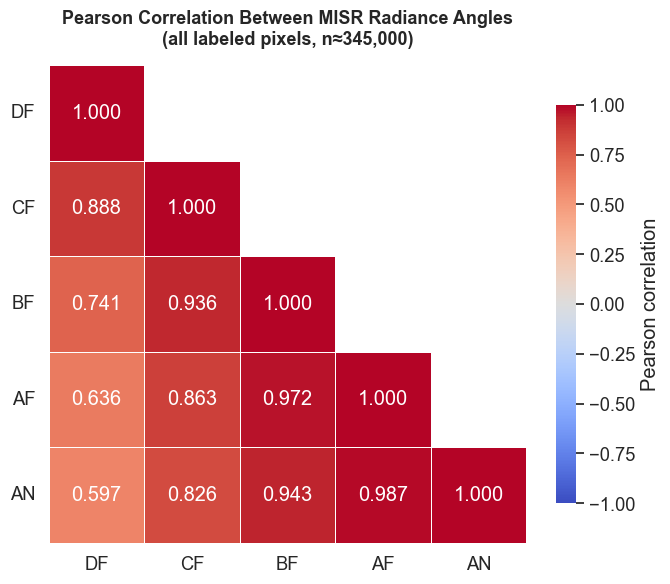

In [28]:
# A) How do the 5 radiance angles relate to each other?

radiance_cols = ['DF', 'CF', 'BF', 'AF', 'AN']

corr_matrix = df_all[radiance_cols].corr()

# this line creates a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(7,6))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Pearson correlation"},
    ax=ax
)

ax.set_title(
    "Pearson Correlation Between MISR Radiance Angles\n(all labeled pixels, n≈345,000)",
    fontsize=13, fontweight="bold", pad=15
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("./results/radiance_correlation_heatmap.pdf", dpi=150, bbox_inches="tight")
plt.show()



#### Interpreation:

This makes a lot of sense, all these features are measuring the same point but at different angles, so this is expected. The pattern that we see here is that the closest they are in angle, the more correlated. And the opposite is true, e.g. AN (0 degrees) and DF (70.5 degrees) are the furthest away and their correlation is the lowest in the heatmap, but still correlated (0.597)

#### Some implications:
When features are highly correlated, they carry overlapping information. If we feed all 5 raw radiances into a model, we are not giving it 5 independent signals. This is called multicollinearity and it has real consequences for modeling:

    - Linear/Logistic Regression  →  coefficients become unstable and hard to interpret.
    - Tree-based models           →  less affected, but still wasteful. The tree will split innecesarily  


Observation 2:
- the residual variation is key. NDAI is already engineered to extract exactly the residual variation that the correlation heatmap shows is present between the extreme angles.

High correlation → angles agree → cloud and ice look the same here
Low correlation  → angles disagree → this disagreement is the cloud signal
                          ↑
                    NDAI captures this


#### Implications for Feature Engineering:
Based on the heatmap, some ideas:
1) PCA on the 5 radiances: since they're correlated, apply PCA to compress them into 2-3 components that capture most variance without redundancy.

2) Ratios and differences between non-adjacent angles: DF↔AN has the most residual variation so NDAI uses them. But maybe try CF↔AN, BF↔AN and see if they add anything NDAI misses.

In [15]:
# B) Do cloud vs. not-cloud pixels look different in raw radiance?

df_labeled = df_all[df_all['label'] != 0].copy()

df_labeled['class'] = df_labeled['label'].map({1: 'Cloud', -1: 'Not Cloud'})

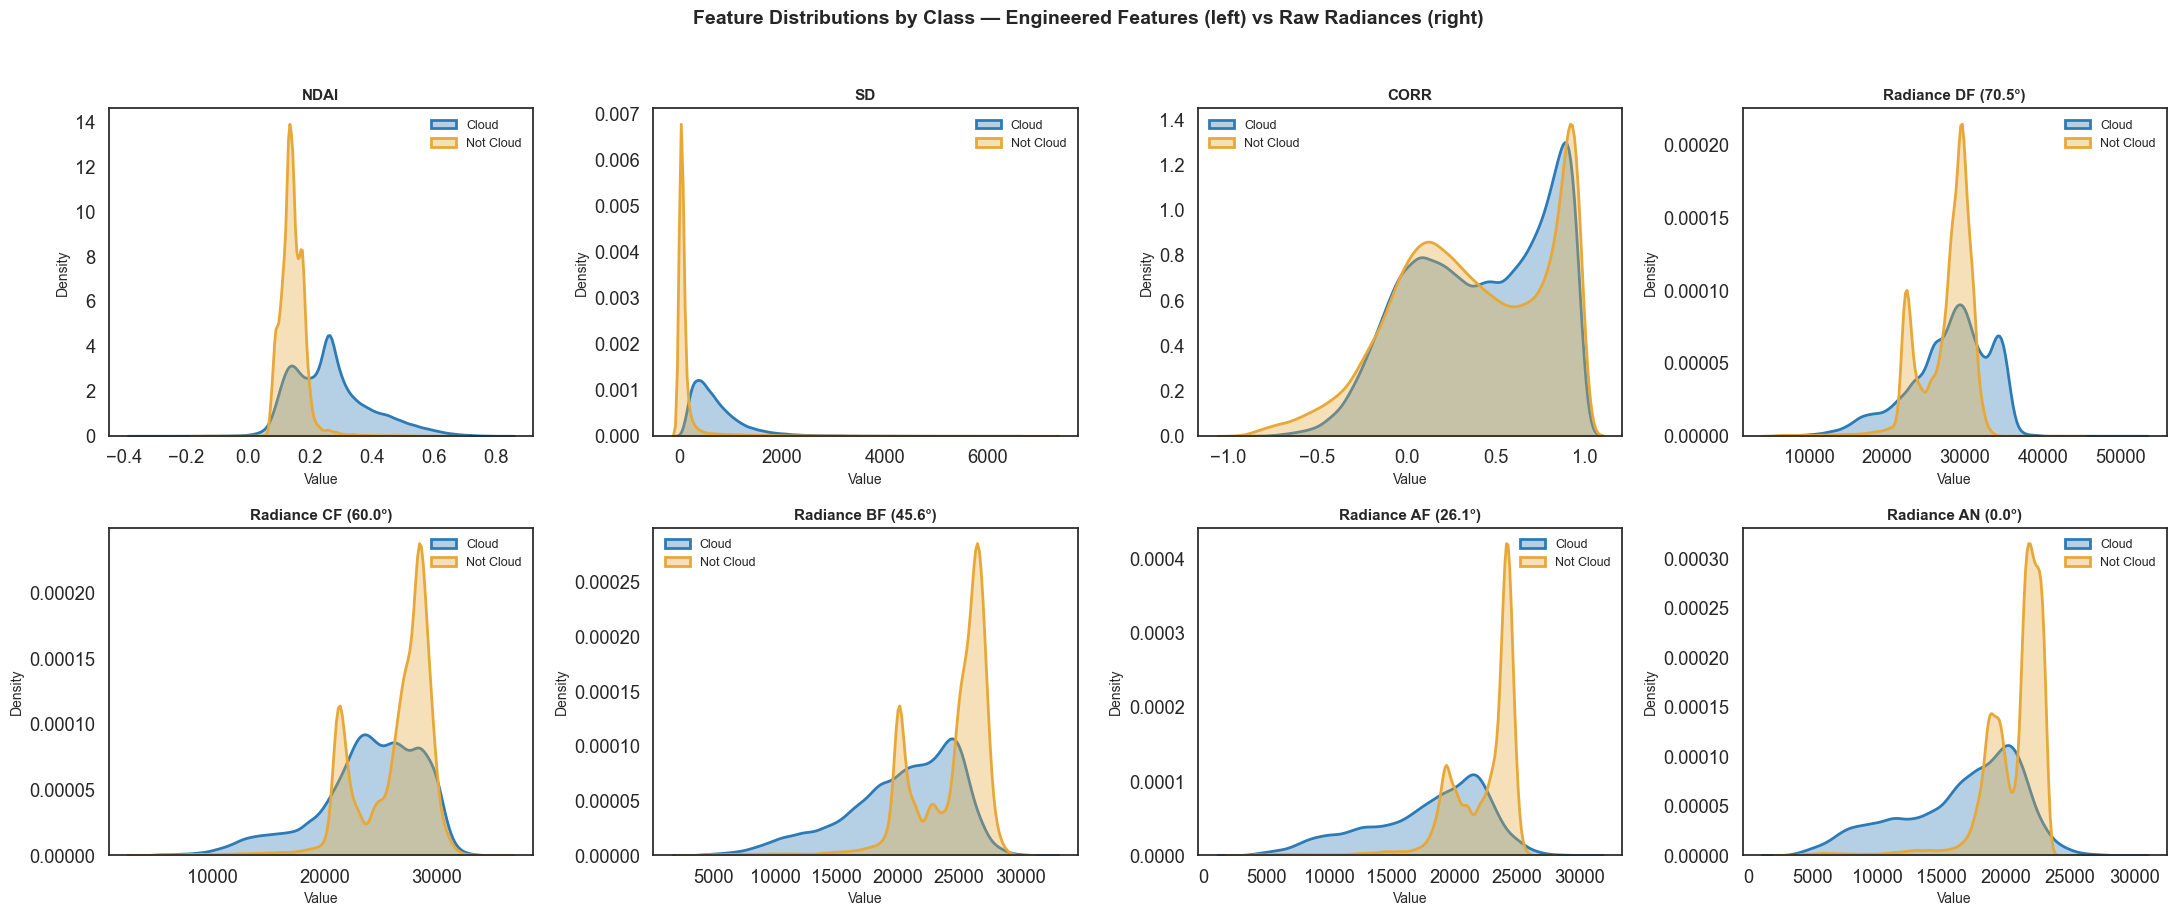


Mean feature values by class:
class      Cloud  Not Cloud
NDAI       0.265      0.143
SD       723.742    163.763
CORR       0.413      0.367
DF     27997.867  27456.424
CF     23911.947  26099.375
BF     20384.506  24192.799
AF     17869.253  22200.414
AN     16567.729  20605.630


In [29]:
# Plot
FEATURES = ["NDAI", "SD", "CORR", "DF", "CF", "BF", "AF", "AN"]

FEATURE_LABELS = {
    "NDAI": "NDAI",
    "SD":   "SD",
    "CORR": "CORR",
    "DF":   "Radiance DF (70.5°)",
    "CF":   "Radiance CF (60.0°)",
    "BF":   "Radiance BF (45.6°)",
    "AF":   "Radiance AF (26.1°)",
    "AN":   "Radiance AN (0.0°)"
}

CLASS_COLORS = {"Cloud": "#2C7BB6", "Not Cloud": "#E8A838"}

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.flatten()

# i selects the subplot, feat selects the column
for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for cls, color in CLASS_COLORS.items():
        subset = df_labeled[df_labeled['class'] == cls][feat]
        sns.kdeplot(
            data=subset,
            ax=ax,
            label=cls,
            color=color,
            fill=True,
            alpha=0.35,
            linewidth=2.0
        )
    ax.set_title(FEATURE_LABELS[feat], fontsize=11, fontweight="bold")
    ax.set_xlabel("Value", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=9, frameon=False)

fig.suptitle(
    "Feature Distributions by Class — Engineered Features (left) vs Raw Radiances (right)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("./results/feature_distributions_by_class.pdf", dpi=150, bbox_inches="tight")
plt.show()

#  quantitative summary ---
summary = (
    df_labeled
    .groupby("class")[FEATURES]
    .mean()
    .round(3)
    .T
)
print("\nMean feature values by class:")
print(summary)



Before even running the previous, we expected the following:


| Feature | Cloud (+1) | Not Cloud (-1) |
|--------|-------------|---------------|
| NDAI | large, positive | near 0 or slightly negative |
| SD | high | low |
| CORR | low | high |


Formula for NDAI = (DF - AN) / (DF + AN)

Using mean table:
  Cloud:     (27997 - 16567) / (27997 + 16567)  =  11430 / 44564  ≈  0.256  ✓
  Not Cloud: (27456 - 20605) / (27456 + 20605)  =   6851 / 48061  ≈  0.143  ✓


Now let's see the mean table for Radiances

| Feature | Cloud | Not Cloud | Difference |
|--------|------|-----------|------------|
| DF | 27997 | 27456 | Cloud higher by 541 |
| CF | 23911 | 26099 | Cloud lower by 2188 |
| BF | 20384 | 24192 | Cloud lower by 3808 |
| AF | 17869 | 22200 | Cloud lower by 4331 |
| AN | 16567 | 20605 | Cloud lower by 4038 |


There is a crossover between DF and CF. At the most extreme forward angle (DF, 70.5°), clouds are slightly brighter. At every other angle including nadir (AN), not-cloud is brighter.

Apparently this is because ice/snow scatters light evenly in all directions, it looks bright from any angle. Clouds scatter mostly forward, they look very bright from the DF direction but dimmer when you look at them from straight down. 

NDAI is capturing exactly this crossover by comparing the extreme forward angle to nadir. The "small" difference becomes meaningful because it is consistent and physically interpretable. 


This also explains why raw radiances fail to separate the classes well overall, the cloud signal is sometimes brighter, sometimes dimmer, depending on the angle. No single radiance value reliably says "cloud."


#### Additional observations:

- Notice the two-humps for not-cloud, this means that "not cloud" category is not a single surface type. It contains at least two distinct subpopulations:
    - Lower peak (~15,000-20,000)  →  darker surfaces: exposed rock, vegetation, ocean, partially melted sea ice (summer darkening)

    - Higher peak (~25,000-30,000) →  bright surfaces: permanent glacial snow, thick sea ice, reflective polar surfaces


- CORR looks very similar for both cases, why?
    - CORR has a mean of 0.413 for cloud vs 0.367 for not-cloud, a difference of only 0.046.
    - Why? Because CORR was designed to catch high-altitude clouds
    - High-altitude cloud  →  appears registered to different locations from different cameras  →  LOW CORR  ✓
    - Low-altitude cloud   →  appears registered to almost the same location from different cameras  →  HIGH CORR ✗ (looks just like a surface to CORR)

    - labeled images are probably low-altitude clouds, CORR cannot detect these


All of the previous observations align with the paper rule:

A pixel is labeled CLEAR if:
SD < 2.0                           (catches smooth surfaces CORR can't distinguish)
OR
CORR > 0.75 AND NDAI < threshold   (catches cloud-free areas CORR can distinguish)

SD handles the case CORR misses, CORR handles the case NDAI might miss, NDAI provides the angular signal.



| Feature | Separates classes? | Why / Why not |
|--------|--------------------|---------------|
| NDAI | Moderately yes | Captures forward scattering crossover; distributions overlap but means differ clearly |
| SD | Strongly yes | Largest relative difference (4.4× in means); cloud texture vs. smooth ice |
| CORR | Weakly yes | Only works for high-altitude clouds; low-altitude clouds fool it |
| DF | Barely | Cloud slightly brighter at this angle only |
| CF, BF, AF, AN | Barely, wrong direction | Not-cloud is actually brighter; confirms Arctic brightness problem |

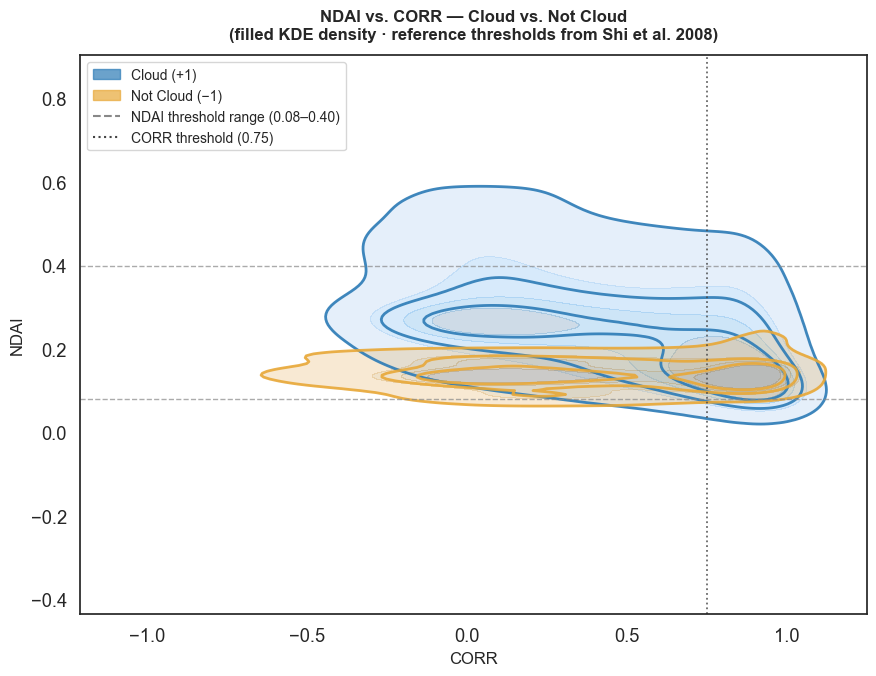

In [30]:
# Step 3 → NDAI vs. CORR scatter plot colored by class
# The idea is: if NDAI and CORR individually showed weak separation, maybe together they separate the classes clearly.

n_sample = 3000

df_cloud    = df_labeled[df_labeled["class"] == "Cloud"].sample(n=n_sample, random_state=42)
df_notcloud = df_labeled[df_labeled["class"] == "Not Cloud"].sample(n=n_sample, random_state=42)
df_sample   = pd.concat([df_cloud, df_notcloud])

fig, ax = plt.subplots(figsize=(9, 7))

# --- layer 1: filled KDE (shows density as shaded regions) ---
for cls, color in CLASS_COLORS.items():
    subset = df_labeled[df_labeled["class"] == cls]
    sns.kdeplot(
        data=subset,
        x="CORR", y="NDAI",
        ax=ax,
        color=color,
        fill=True,
        alpha=0.25,
        levels=5,
        bw_adjust=1.5,
        thresh=0.08
    )

# --- layer 2: contour lines on top ---
for cls, color in CLASS_COLORS.items():
    subset = df_labeled[df_labeled["class"] == cls]
    sns.kdeplot(
        data=subset,
        x="CORR", y="NDAI",
        ax=ax,
        color=color,
        fill=False,
        alpha=0.9,
        levels=4,
        linewidths=2.0,
        bw_adjust=1.5,
        thresh=0.08
    )

# --- reference lines ---
ax.axhline(y=0.08, color="#888888", linestyle="--", linewidth=1.0, alpha=0.7)
ax.axhline(y=0.40, color="#888888", linestyle="--", linewidth=1.0, alpha=0.7)
ax.axvline(x=0.75, color="#444444", linestyle=":",  linewidth=1.3, alpha=0.8)

# --- clean manual legend ---
handles = [
    mpatches.Patch(color=CLASS_COLORS["Cloud"],     alpha=0.7, label="Cloud (+1)"),
    mpatches.Patch(color=CLASS_COLORS["Not Cloud"], alpha=0.7, label="Not Cloud (−1)"),
    plt.Line2D([0], [0], color="#888888", linestyle="--", linewidth=1.5,
               label="NDAI threshold range (0.08–0.40)"),
    plt.Line2D([0], [0], color="#444444", linestyle=":",  linewidth=1.5,
               label="CORR threshold (0.75)"),
]
ax.legend(handles=handles, fontsize=10, frameon=True,
          edgecolor="#cccccc", loc="upper left")

ax.set_xlabel("CORR", fontsize=12)
ax.set_ylabel("NDAI", fontsize=12)
ax.set_title(
    "NDAI vs. CORR — Cloud vs. Not Cloud\n"
    "(filled KDE density · reference thresholds from Shi et al. 2008)",
    fontsize=12, fontweight="bold", pad=12
)

plt.tight_layout()
plt.savefig("./results/ndai_vs_corr_kde.pdf", dpi=150, bbox_inches="tight")
plt.show()



Interpretation of the graph above:
- Each countour ring is like a topographic map, the innermost ring is where the most pixels are concentrated, outer rings have fewer pixels
- The overlap regions are probably the most difficult for the modelling. I assume it's low-altitude clouds that have high CORR because they register similarly to the surface from different angles


But I am having a bit of trouble interpreting this graph corrrectly, let's see the numbers

In [18]:
# For each class, count what fraction falls in each quadrant
# defined by the paper's thresholds

ndai_thresh = 0.20   # approximate midpoint of the 0.08-0.40 range
corr_thresh = 0.75

print(f"Using CORR threshold = {corr_thresh}, NDAI threshold = {ndai_thresh}\n")
print(f"{'Region':<35} {'Cloud':>10} {'Not Cloud':>12}")
print("-" * 60)

regions = {
    "High CORR + Low NDAI  (→ clear)":  (df_labeled["CORR"] >  corr_thresh) & (df_labeled["NDAI"] <  ndai_thresh),
    "High CORR + High NDAI":             (df_labeled["CORR"] >  corr_thresh) & (df_labeled["NDAI"] >= ndai_thresh),
    "Low CORR  + Low NDAI":              (df_labeled["CORR"] <= corr_thresh) & (df_labeled["NDAI"] <  ndai_thresh),
    "Low CORR  + High NDAI (→ cloud)":  (df_labeled["CORR"] <= corr_thresh) & (df_labeled["NDAI"] >= ndai_thresh),
}

for region_name, mask in regions.items():
    for cls in ["Cloud", "Not Cloud"]:
        cls_mask   = df_labeled["class"] == cls
        total      = cls_mask.sum()
        count      = (mask & cls_mask).sum()
        pct        = count / total * 100
    
    cloud_pct     = (mask & (df_labeled["class"] == "Cloud")).sum()     / (df_labeled["class"] == "Cloud").sum()     * 100
    notcloud_pct  = (mask & (df_labeled["class"] == "Not Cloud")).sum() / (df_labeled["class"] == "Not Cloud").sum() * 100
    print(f"{region_name:<35} {cloud_pct:>9.1f}%  {notcloud_pct:>10.1f}%")


Using CORR threshold = 0.75, NDAI threshold = 0.2

Region                                   Cloud    Not Cloud
------------------------------------------------------------
High CORR + Low NDAI  (→ clear)          16.8%        22.9%
High CORR + High NDAI                    10.1%         3.3%
Low CORR  + Low NDAI                     16.6%        72.4%
Low CORR  + High NDAI (→ cloud)          56.5%         1.4%


Interpretation from the table above:
- 72.4% of not-cloud has low CORR, this contradicts the expectation of "not-cloud = high CORR", but this can make sense because not-cloud is not just ice/snow, it's also:
    - rocky exposed terrain → rough → low CORR
    - partially melted sea ice → textured → low CORR
    - darker summer surfaces → variable → low CORR

Only the brightest, smoothest ice patches give high CORR

so it's again like what we saw in the density graphs with two peaks, the not-cloud population has two mixed populations together

Back to the table with results:

| Condition | Cloud | Not Cloud | What this means |
|----------|------|-----------|----------------|
| Low CORR + High NDAI | 56.5% | 1.4% | → almost pure cloud signal |
| Low CORR + Low NDAI | 16.6% | 72.4% | → mostly not-cloud (rough surfaces) |
| High CORR + Low NDAI | 16.8% | 22.9% | → slightly leaning towards not-cloud |
| High CORR + High NDAI | 10.1% | 3.3% | → confused zone (low-altitude clouds) |

But NDAI is doing most of the work here

| Condition | Clouds | Not Cloud | Interpretation |
|----------|--------|-----------|----------------|
| NDAI ≥ 0.20 | 66.6% | 4.7% | Very clean cloud signal |
| NDAI < 0.20 | 33.4% | 95.3% | Mostly not-cloud |

Just thresholding NDAI at 0.20 already captures 66.6% of all clouds

CORR adds value only inside the low-NDAI zone

- Low CORR + Low NDAI → 72.4% not-cloud (rough surfaces the algorithm can still label clear)
- High CORR + Low NDAI → 22.9% not-cloud (smooth ice)


In summary:

    NDAI is the primary discriminator, 66.6% of cloud pixels have NDAI ≥ 0.20 compared to only 4.7% of not-cloud pixels, while CORR adds secondary value by disambiguating low-NDAI pixels, particularly distinguishing smooth ice (high CORR) from rough terrain (low CORR). The 16.8% of cloud pixels falling in the 'clear' region (high CORR, low NDAI) likely represent low-altitude clouds that both features fail to detect, consistent with the known limitation reported in Shi et al. (2008)`


### Question 3: 

Split your data into training, validation, and test sets (or training and test, with some cross-validation scheme over the training set). Justify your choice of split based on how it reflects the challenges with possible future applications of your cloud detection algorithm.

Based on all the previous information, I believe it's best to do training and test, with cross-validation scheme over the training set because 3 images is not a lot, so we need the most information possible to train it correctly, and we need 1 image at the very least for testing. Unfortunately, no budget for validation here.

The split will be temporal holdout (train O012791 + O013257, test O013490), since this mirrors real deployment (train on past, predict on future). But something to note is that we are only training images in spring, not in summer (when ice melts), something to be cautious, but again, with only 3 images, this is the best we can do.

To summarize:

    We designate O013490 as the held-out test set and train on O012791 and O013257, reflecting a temporal holdout strategy. In real deployment, a cloud detection algorithm would be trained on historically labeled data and applied to future satellite passes, never having seen the test conditions during training. Using the most recent orbit as the test set best simulates this scenario. Within the training set we apply 5-fold StratifiedKFold cross-validation at the pixel level to tune hyperparameters while preserving class balance across folds. We acknowledge two limitations of this design: first, with only 3 labeled images our test estimate derives from a single atmospheric condition, yielding high uncertainty in reported performance; second, our training set covers a narrower seasonal window (April–June) than the full April–September collection period, meaning the model may underperform on late-summer conditions where surface ice has partially melted.

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, KFold

# keep only labeled pixels
df_split = df_all[df_all['label'] != 0].copy()

# define feature columns
# autoencoder will add one more feature later
FEATURE_COLS = ["NDAI", "SD", "CORR", "DF", "CF", "BF", "AF", "AN"]

# designate test image (temporal holdout)
TEST_IMAGE = "O013490"

df_test = df_split[df_split['image'] == TEST_IMAGE]
df_train = df_split[df_split['image'] != TEST_IMAGE]

# extract arrays for sklearn
X_train = df_train[FEATURE_COLS].values # shape is (N_train, 8)
y_train = df_train['label'].values # shape is (N_train,)  values: +1 or -1

X_test  = df_test[FEATURE_COLS].values    # shape (N_test, 8)
y_test  = df_test["label"].values         # shape (N_test,)

# CV splitter (used later during model training — not pre-split) 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# StratifiedKFold preserves the cloud/not-cloud class ratio in each fold
# n_splits=5 → 80% train / 20% validate per fold, 5 rounds
# shuffle=True → randomizes pixel order before splitting (important: pixels are ordered spatially in the DataFrame, so without shuffle one fold would get all top-of-image pixels)
# random_state=42 → reproducibility

# sanity checks 
print("=== Split Summary ===\n")
print(f"Training pixels : {len(X_train):>8,}  (O012791 + O013257)")
print(f"Test pixels     : {len(X_test):>8,}  (O013490)\n")

for name, y in [("Training", y_train), ("Test", y_test)]:
    total  = len(y)
    cloud  = (y ==  1).sum()
    clear  = (y == -1).sum()
    print(f"{name} class balance:")
    print(f"  Cloud     (+1): {cloud:>7,}  ({cloud/total*100:.1f}%)")
    print(f"  Not Cloud (-1): {clear:>7,}  ({clear/total*100:.1f}%)\n")

print(f"CV strategy: StratifiedKFold, {cv.n_splits} folds")
print("(CV splitter will be used in Part 3 during model fitting)")



=== Split Summary ===

Training pixels :  125,598  (O012791 + O013257)
Test pixels     :   82,083  (O013490)

Training class balance:
  Cloud     (+1):  41,712  (33.2%)
  Not Cloud (-1):  83,886  (66.8%)

Test class balance:
  Cloud     (+1):  39,253  (47.8%)
  Not Cloud (-1):  42,830  (52.2%)

CV strategy: StratifiedKFold, 5 folds
(CV splitter will be used in Part 3 during model fitting)


| Object | Type | Used for |
|------|------|-----------|
| df_train | DataFrame | Human-readable training data with column names |
| df_test | DataFrame | Human-readable test data — do not touch until Part 3 |
| X_train, y_train | NumPy arrays | Input to sklearn models |
| X_test, y_test | NumPy arrays | Final evaluation only |
| cv | StratifiedKFold object | Passed to `cross_val_score()` or used in loops during model fitting |

Notice that:
- Pixel counts are consistent with the ~71.5% labeling rate the paper mention
- Training is larger than test, 125k vs 82k, as expected with 2 images training and 1 test
- the class distribution is slightly imbalanced towards not-cloud in the training set (33.2% vs 66.8%)
    - This means that when training classifiers, use 'class_weight="balanced"' (in sklearn) so the model doesn't just learn to predict not-cloud by default, like this:

    LogisticRegression(class_weight="balanced")
    RandomForestClassifier(class_weight="balanced")


Summary:

    The training set is 33.2% cloud vs. 66.8% not-cloud, while the test image is nearly balanced (47.8% vs. 52.2%), introducing a class distribution shift that reflects realistic deployment conditions where cloud fraction varies across observations. We address this by using class-weighted models 

#### Part 4: Data Cleaning

I will check the following

| Issue | Reasons |
|------|----------------|
| NaN values | Sensor didn't record a measurement at certain angles |
| Zero or negative radiances | Physically impossible, light intensity can't be ≤ 0 |
| CORR outside [-1, 1] | Floating point errors in the correlation computation |
| Extreme outliers | Cosmic ray hits, sensor glitches, atmospheric artifacts, etc |
| Duplicate pixel coordinates | Same (x, y) recorded twice in one image |

In [20]:
print("=" * 50)
print("1. NaN Values")
print("=" * 50)
print(df_all[FEATURE_COLS].isnull().sum().to_string())
print(f"\nTotal NaN cells: {df_all[FEATURE_COLS].isnull().sum().sum()}")

# all good here

1. NaN Values
NDAI    0
SD      0
CORR    0
DF      0
CF      0
BF      0
AF      0
AN      0

Total NaN cells: 0


In [21]:
print("\n" + "=" * 50)
print("2. ZERO OR NEGATIVE RADIANCES (physically impossible)")
print("=" * 50)
radiance_cols = ["DF", "CF", "BF", "AF", "AN"]
for col in radiance_cols:
    n_zero     = (df_all[col] == 0).sum()
    n_negative = (df_all[col]  < 0).sum()
    print(f"  {col}:  zero={n_zero:,}   negative={n_negative:,}")

# all good here


2. ZERO OR NEGATIVE RADIANCES (physically impossible)
  DF:  zero=0   negative=0
  CF:  zero=0   negative=0
  BF:  zero=0   negative=0
  AF:  zero=0   negative=0
  AN:  zero=0   negative=0


In [22]:
print("\n" + "=" * 50)
print("3. CORR OUTSIDE [-1, 1] (invalid correlation values)")
print("=" * 50)
n_above =  (df_all["CORR"] >  1).sum()
n_below =  (df_all["CORR"] < -1).sum()
print(f"  CORR > 1  : {n_above:,}")
print(f"  CORR < -1 : {n_below:,}")

# all good here


3. CORR OUTSIDE [-1, 1] (invalid correlation values)
  CORR > 1  : 0
  CORR < -1 : 0


In [23]:
print("\n" + "=" * 50)
print("4. EXTREME OUTLIERS (beyond 3 standard deviations)")
print("=" * 50)
for col in FEATURE_COLS:
    mean = df_all[col].mean()
    std  = df_all[col].std()
    n_outliers = (np.abs(df_all[col] - mean) > 3 * std).sum()
    pct = n_outliers / len(df_all) * 100
    print(f"  {col:<6}: {n_outliers:>7,}  ({pct:.2f}%)")

# Not all outliers are errors (extreme cloud conditions are real), but extreme ones might indicate sensor glitches
# either way this is an entire challenge on its own, I can try to instead see if there's any pattern, but would recommended against removing these


4. EXTREME OUTLIERS (beyond 3 standard deviations)
  NDAI  :   7,721  (2.24%)
  SD    :   7,734  (2.24%)
  CORR  :     883  (0.26%)
  DF    :   4,492  (1.30%)
  CF    :   5,129  (1.49%)
  BF    :   4,933  (1.43%)
  AF    :   4,768  (1.38%)
  AN    :   5,338  (1.55%)


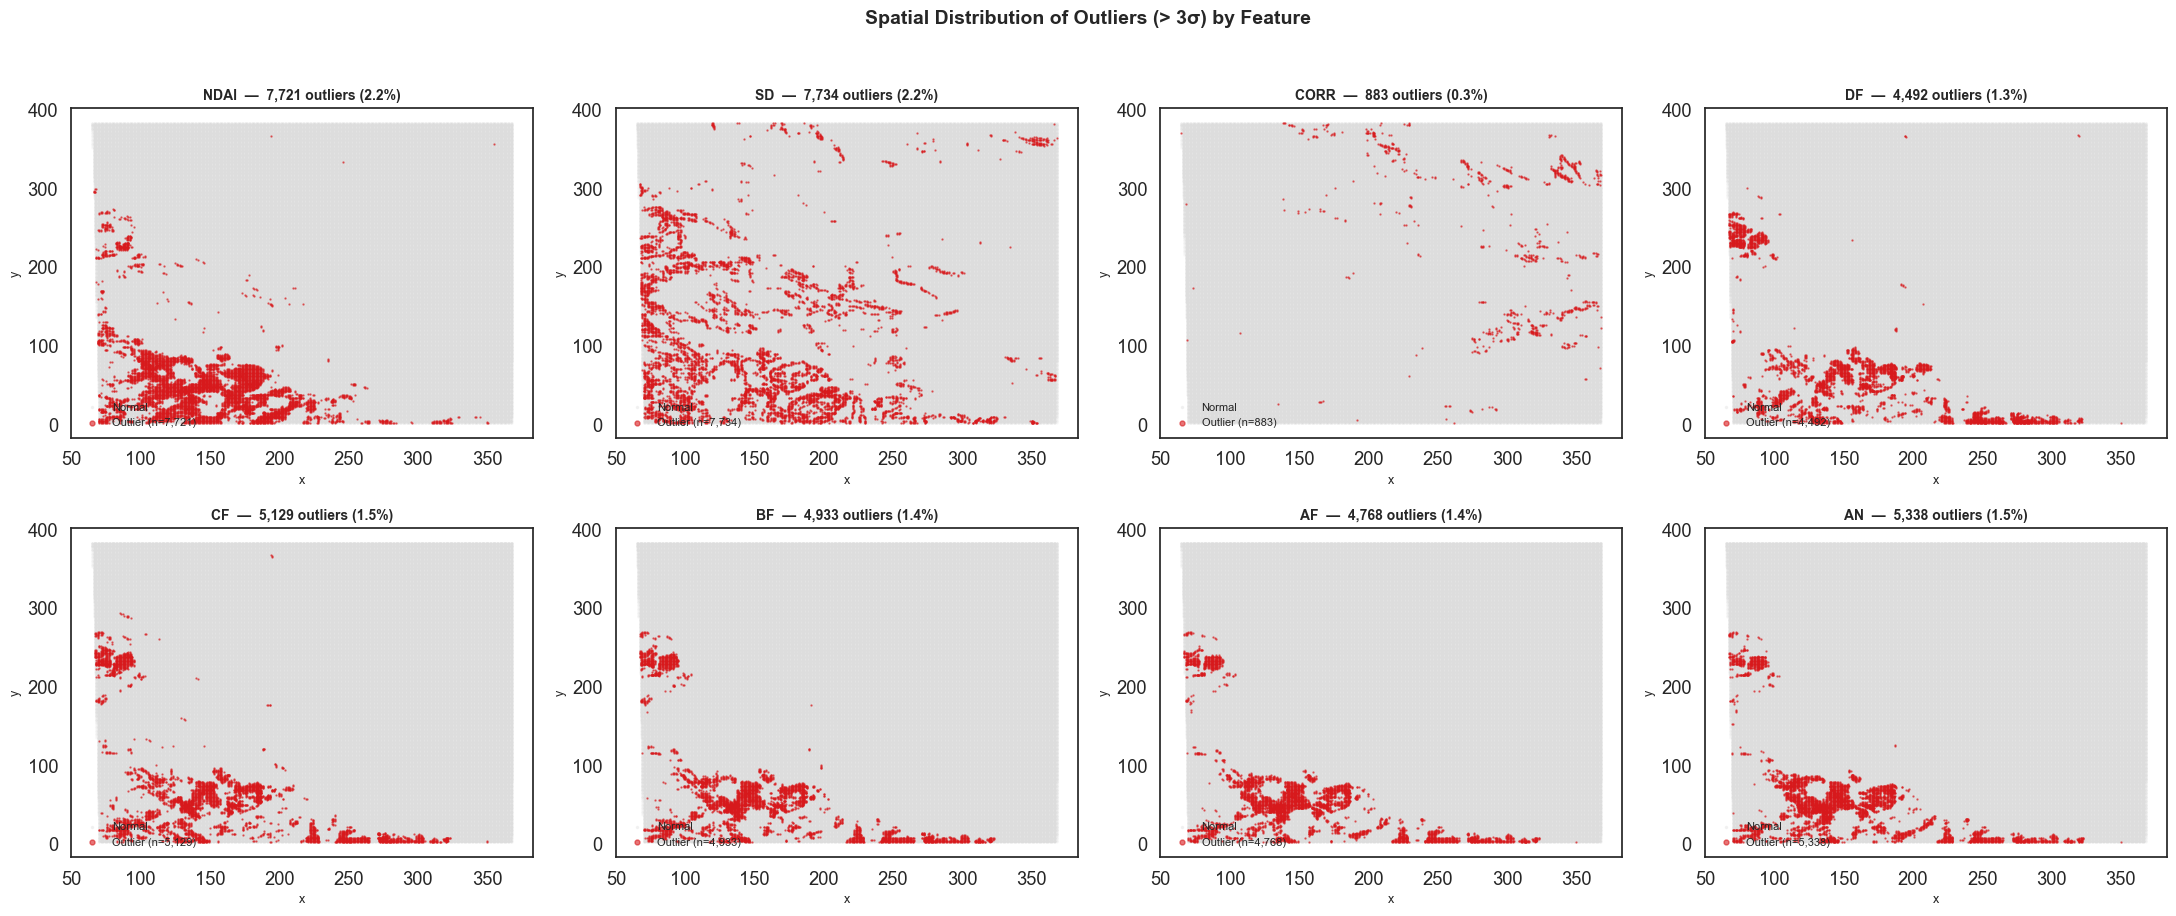

In [24]:
# Do outliers cluster at image edges?

FEATURE_COLS = ["NDAI", "SD", "CORR", "DF", "CF", "BF", "AF", "AN"]

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    mean = df_all[col].mean()
    std  = df_all[col].std()

    # Boolean mask: True = outlier for this feature
    is_outlier = np.abs(df_all[col] - mean) > 3 * std

    # Plot normal pixels in light gray
    ax.scatter(
        df_all.loc[~is_outlier, "x"],
        df_all.loc[~is_outlier, "y"],
        c="#DDDDDD", s=0.1, alpha=0.3,
        rasterized=True, label="Normal"
    )
    # Plot outliers in red on top
    ax.scatter(
        df_all.loc[is_outlier, "x"],
        df_all.loc[is_outlier, "y"],
        c="#D7191C", s=0.5, alpha=0.6,
        rasterized=True,
        label=f"Outlier (n={is_outlier.sum():,})"
    )

    ax.set_title(f"{col}  —  {is_outlier.sum():,} outliers ({is_outlier.mean()*100:.1f}%)",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("x", fontsize=9)
    ax.set_ylabel("y", fontsize=9)
    ax.legend(fontsize=8, frameon=False, markerscale=5)

fig.suptitle("Spatial Distribution of Outliers (> 3σ) by Feature",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
# plt.savefig("../results/outlier_spatial_map.png", dpi=150, bbox_inches="tight")
plt.show()


What to look for from the graph above:

Outliers cluster at image edges  →  likely artifacts from incomplete patch computation

Outliers scattered throughout    →  likely real extreme atmospheric conditions

Here:

Outliers are NOT at image edges. They cluster in the lower-left region (low x, low y) across all features. This is a specific geographic area, likely coastal Greenland terrain with extreme surface properties (sharp mountain ridges, coastline transitions, rough terrain). The paper actually mentions this: "The major reason for errors in the ELCM algorithm is that CORR is low even though there is no cloud. The low correlation is a result of poor terrain data registration, which usually occurs at sharp elevation changes (e.g., the coastline of Greenland)."


In summary, these outliers are okay.

Summary (for report later):

    Outlier analysis (>3σ) identified 0.26–2.24% of pixels as extreme depending on the feature. Spatial inspection revealed these outliers cluster in the lower-left region of the image space, consistent with the Greenland coastal terrain identified by Shi et al. (2008) as problematic due to poor terrain registration at sharp elevation changes. The simultaneous outlier analysis further showed that 1,913 pixels are simultaneously extreme across 5+ features, a pattern inconsistent with random sensor noise and consistent with coherent extreme physical conditions. We therefore retain all outliers, noting that model performance in this terrain region may be lower than average.

In [25]:
print("\n" + "=" * 50)
print("5. DUPLICATE PIXEL COORDINATES WITHIN SAME IMAGE")
print("=" * 50)
dupes = df_all.duplicated(subset=["image", "y", "x"]).sum()
print(f"  Duplicate (image, y, x) combinations: {dupes:,}")

# all good here


5. DUPLICATE PIXEL COORDINATES WITHIN SAME IMAGE
  Duplicate (image, y, x) combinations: 0


In [ ]:
print("\n" + "=" * 50)
print("6. VALUE RANGES SUMMARY")
print("=" * 50)
print(df_all[FEATURE_COLS].agg(["min", "max", "mean"]).round(2).T.to_string())

# all looks good


6. VALUE RANGES SUMMARY
          min       max      mean
NDAI    -0.36      0.82      0.19
SD      13.33   8248.58    591.67
CORR    -0.94      0.98      0.46
DF    4904.00  51807.12  27529.41
CF    3536.75  36623.75  25077.10
BF    2777.75  33268.25  22582.97
AF    2170.50  32085.00  20452.26
AN    2089.25  30824.50  18999.34


## EDA Summary

**Data:** 3 labeled MISR images (~345,000 total pixels, ~207,000 labeled)
covering Arctic path 26, April–June 2002.

**Key findings:**
- Radiance angles are highly correlated (r = 0.60–0.97), confirming redundancy in raw measurements
- NDAI is the strongest single separator: 66.6% of cloud pixels have NDAI ≥ 0.20 vs. only 4.7% of not-cloud pixels
- SD shows the largest mean difference (4.4× higher for cloud)
- CORR alone is weak due to low-altitude clouds fooling it
- Raw radiances show minimal class separation, confirming the Arctic brightness problem described in Shi et al. (2008)
- Class distribution shifts between train (33% cloud) and test (48% cloud), requiring class-weighted models in Part 3
- Outliers cluster geographically in Greenland coastal terrain, retained as physically real extreme conditions
